In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
# sys.path.append('../../../')
# from mount_drive import mount_s_drive

In [2]:
import pandas as pd
import os
import sys
import pymc as pm
import pymc_bart as pmb
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from eICUUtil import *


In [3]:
columns= [
    'patientunitstayid','gender','age','bmi',
    'nurse_first_Non-Invasive BP Systolic',
    'nurse_first_Non-Invasive BP Diastolic',
    'nurse_first_Non-Invasive BP Mean',
    'nurse_first_Heart Rate',
    'nurse_first_O2 Saturation',
    'nurse_first_Temperature (C)',
    'lab_first_Respiratory Rate',
    'lab_first_FiO2',
    'nurse_first_GCS Total',
    'nurse_first_Motor','FirstGCS','LastGCS','LastGCS15',
    'nurse_first_QTc',
    'lab_first_pH','lab_first_paO2','lab_first_paCO2',
    'lab_first_bicarbonate','lab_first_lactate',
    'lab_first_WBC x 1000','lab_first_Hgb','lab_first_platelets x 1000',
    'lab_first_sodium','lab_first_potassium','lab_first_BUN',
    'lab_first_creatinine','lab_first_calcium','lab_first_magnesium',
    'lab_first_glucose','lab_first_troponin - I','lab_first_troponin - T',
    'diagnosis_initial rhythm: ventricular fibrillation',
    'diagnosis_ventricular fibrillation',
    'diagnosis_ventricular tachycardia',
    'diagnosis_initial rhythm: ventricular tachycardia',
    'diagnosis_initial rhythm: pulseless electrical activity',
    'diagnosis_initial rhythm: asystole',
    # 'FirstMGCS',
    'hypothermia_time',
    'Hypothermia'
]

import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'Hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')
    # Preprocessing
    # print(myPredictorsDf['hypothermia_time'])
    myFilter = (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
    myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime']) #& (myPredictorsDf['FirstMGCSTime'] < 360)
    myPredictorsDf.loc[myPredictorsDf['FirstGCS'] == 'Unable to score due to medication', 'FirstGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['FirstMGCS'] == 'Unable to score due to medication', 'FirstMGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['LastMGCS'] == 'Unable to score due to medication', 'LastMGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['LastGCS'] == 'Unable to score due to medication', 'LastGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
    myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
    myPredictorsDf.LastGCS15 = 0
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.nurse_first_Motor != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myFilter & myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x]

    # Get output data
    myXValue = myPredictorsDf.drop(columns= myColumns + ['FirstGCS',
                                                         'LastMGCSTime', 
                                                         'FirstMGCSTime', 'LastMGCSPositive', 'LastMGCS' , 
                                                         'apacheadmissiondx', 'hospitaladmittime24', 
                                                         'FirstGCSTime', 'LastGCSTime', 'LastGCS', 
                                                         'hospitaldischargestatus', 
                                                         'LastGCS15', 'hospitaladmitsource', 
                                                         'DeathAtDischarge', 'patientunitstayid'])
    # myXValue = myXValue[columns]
    myXValue = myXValue
    # myXValue.FirstGCS = myXValue.FirstGCS.astype(float)
    # myXValue.FirstMGCS = myXValue.FirstMGCS.astype(float)
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [4]:
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'DeathAtDischarge', 
                                                                         aTreatmentColumn = 'Hypothermia', 
                                                                         aDropColumns=[], aSkipTemp = True) 

/local/mbranda1/3210227/ipykernel_1898178/269802785.py:36: DtypeWarning: Columns (2188,2190) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')


In [5]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=10)
    myImputer.set_output(transform="pandas")
    # myCovariates = getCovariatePreprocessor(['bin__' + 'Hypothermia'])
    myImputer.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer)]

In [6]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [7]:

with pm.Model() as model:
    X_shared = pm.Data('X_shared', X_train_transf)
    y_shared = pm.Data('y_shared', y_train)
    u = pmb.BART('u', X = X_shared, Y= y_train, m=30)
    p = 1 / (1 + np.exp(-u))
    y_obs= pm.Bernoulli('y_obs', p=p, observed = y_shared)
    trace = pm.sample(50, return_inferencedata=True)
    # trace = az.from_netcdf('bart_model_tracedc.nc')
# Save trace 
# az.to_netcdf(trace, 'bart_model_tracedc.nc')

Only 50 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Multiprocess sampling (4 chains in 4 jobs)
PGBART: [u]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 50 draw iterations (4_000 + 200 draws total) took 18 seconds.
The number of samples is too small to check convergence reliably.


In [8]:
import arviz as az
az.to_netcdf(trace, 'bart_model_tracedc.nc')

'bart_model_tracedc.nc'

In [9]:
with model:
    pm.set_data({'X_shared': X_train_transf, 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    # Calculate the mean predicted probability
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_train, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_train, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

Sampling: [y_obs]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

ROC AUC: 0.80
Accuracy: 0.73


In [10]:
with model:
    pm.set_data({'X_shared': X_test_transf, 'y_shared': y_test})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

Sampling: [u, y_obs]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

ROC AUC: 0.78
Accuracy: 0.70


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'eICU BART Calibration Plot'}, xlabel='Mean predicted probability', ylabel='Observed event rate'>)

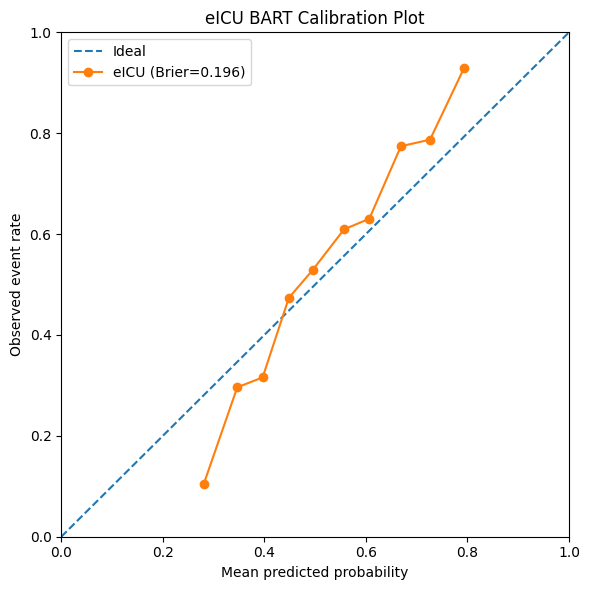

In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def calibration_intercept_slope(y_true, y_prob, eps=1e-6):
    """
    Compute calibration intercept and slope by regressing outcome on logit(predicted probability).
    Ideal intercept = 0, slope = 1.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_prob = np.clip(y_prob, eps, 1 - eps)

    logit_p = np.log(y_prob / (1 - y_prob))
    X = sm.add_constant(logit_p)

    fit = sm.Logit(y_true, X).fit(disp=False)

    intercept = fit.params[0]
    slope = fit.params[1]

    return intercept, slope

def calibration_metrics(y_true, y_prob):
    """
    Return a small dict of discrimination + calibration metrics.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    intercept, slope = calibration_intercept_slope(y_true, y_prob)

    return {
        "n": len(y_true),
        "event_rate": float(np.mean(y_true)),
        "auc": float(roc_auc_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "calibration_intercept": float(intercept),
        "calibration_slope": float(slope),
    }

def plot_calibration_curve_one(y_true, y_prob, title="", n_bins=10, ax=None):
    """
    Reliability diagram / calibration curve.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    frac_pos, mean_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=n_bins,
        strategy="quantile"
    )

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.plot(mean_pred, frac_pos, marker="o")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    return ax
def plot_calibration_curve_multi(model_preds, y_true, title="", n_bins=10):
    """
    model_preds: dict like {"XGBoost": probs1, "NN": probs2, "BART": probs3}
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle="--", label="Ideal")

    for model_name, y_prob in model_preds.items():
        frac_pos, mean_pred = calibration_curve(
            y_true,
            y_prob,
            n_bins=n_bins,
            strategy="quantile"
        )
        brier = brier_score_loss(y_true, y_prob)
        ax.plot(mean_pred, frac_pos, marker="o", label=f"{model_name} (Brier={brier:.3f})")

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    return fig, ax

def build_calibration_table(results_dict):
    """
    results_dict structure:
    {
        ("eICU", "Neuro", "XGBoost"): (y_true, y_prob),
        ("eICU", "Neuro", "NN"): (y_true, y_prob),
        ...
    }
    """
    rows = []

    for (dataset, outcome, model), (y_true, y_prob) in results_dict.items():
        m = calibration_metrics(y_true, y_prob)
        m.update({
            "dataset": dataset,
            "outcome": outcome,
            "model": model
        })
        rows.append(m)

    df = pd.DataFrame(rows)
    df = df[
        [
            "dataset", "outcome", "model", "n", "event_rate",
            "auc", "brier", "calibration_intercept", "calibration_slope"
        ]
    ].sort_values(["dataset", "outcome", "model"]).reset_index(drop=True)

    return df
results_dict = {
    ("eICU", "Mortality", "NN"): (y_test, predicted_probs),
    # ...
}

calib_table = build_calibration_table(results_dict)
calib_table.round(3)
plot_calibration_curve_multi({"eICU":predicted_probs}, y_test, "eICU BART Calibration Plot")

In [14]:
calib_table

,dataset,outcome,model,n,event_rate,auc,brier,calibration_intercept,calibration_slope
0,eICU,Mortality,NN,553,0.542495,0.782398,0.19607,0.010032,1.74057


In [37]:
myXValueModified1 = X_train.copy()
myXValueModified1['Hypothermia'] = 1.0
myXValueModified2 = X_train.copy()
myXValueModified2['Hypothermia'] = 0.0
with model:
    pm.set_data({'X_shared': myPipeline.transform(myXValueModified1), 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs1 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

with model:
    pm.set_data({'X_shared': myPipeline.transform(myXValueModified2), 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs2 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data



Sampling: [u, y_obs]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [u, y_obs]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [25]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
# y_pred_prob = myBestModel.predict_proba(X_test)[:, 1]
def bootstrap_auc_ci(y_true, y_score, n_bootstraps=2000, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []

    for _ in range(n_bootstraps):
        idx = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue  # skip invalid bootstrap
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))

    aucs = np.array(aucs)
    return (
        np.mean(aucs),
        np.percentile(aucs, 2.5),
        np.percentile(aucs, 97.5),
    )

auc, ci_low, ci_high = bootstrap_auc_ci(np.array(y_test), predicted_probs)
print(f"AUC = {auc:.3f} (95% CI {ci_low:.3f}–{ci_high:.3f})")


AUC = 0.816 (95% CI 0.778–0.852)


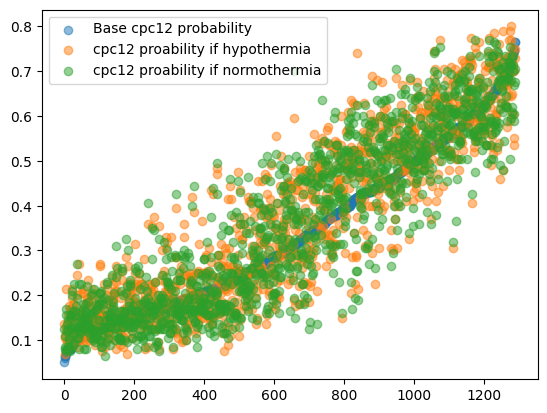

In [42]:
myYPred =  (predicted_probs1 - predicted_probs2)
myYPred = predicted_probs
myDfPreds = pd.DataFrame()
myDfPreds['base'] = predicted_probs
myDfPreds['group1'] = predicted_probs1
myDfPreds['group2'] = predicted_probs2
myDfPreds.sort_values(by=['base'], inplace=True)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['base'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group1'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group2'], alpha = 0.5)
plt.legend(['Base cpc12 probability', 'cpc12 proability if hypothermia', 'cpc12 proability if normothermia'])


In [43]:
myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = myYPred

In [24]:
myNewDf

,predicted_effect
0,0.490
1,0.615
2,0.625
3,0.655
4,0.545
...,...
1721,0.450
1722,0.750
1723,0.555
1724,0.400


Optimization terminated successfully.
         Current function value: 0.634882
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.634879
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 0.00702560391937368
p-value: 0.9332004402120783
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                 1289
Model:                          Logit   Df Residuals:                     1286
Method:                           MLE   Df Model:                            2
Date:                Sun, 21 Dec 2025   Pseudo R-squ.:                0.006979
Time:                        15:15:06   Log-Likelihood:                -818.36
converged:                       True   LL-Null:                       -824.11
Covariance Type:            nonrobust   LLR p-value:                  0.003177
                     

np.float64(0.9332004402120783)

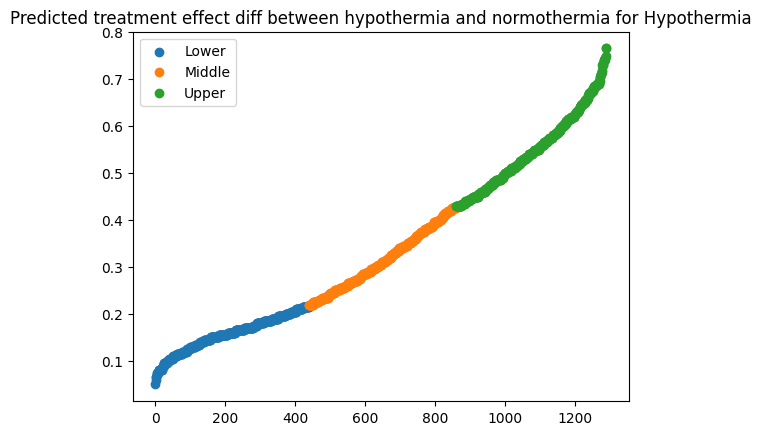

In [45]:
low_third, upper_third, myNewDf = plotPredictedTreatmentEffect(myNewDf, 'Hypothermia')
getTreatmentEffectDiffDataFrame(X_train_transf, y_train, myNewDf, 'LastMGCSPositive', 'bin__Hypothermia', False)

In [35]:
myData = pd.concat([X_train['Hypothermia'].reset_index(), myNewDf['predicted_effect_group'].reset_index(), y_train.reset_index()], axis=1)


In [39]:
myData.groupby(['Hypothermia', 'predicted_effect_group']).agg({'LastMGCSPositive': 'sum'})

LastMGCSPositive
Hypothermia predicted_effect_group                  
0           Lower                                215
            Middle                               192
            Upper                                195
1           Lower                                 35
            Middle                                40
            Upper                                 37